In [1]:
import os
from google.colab import drive

# Google Drive'a bağlanın
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import zipfile
from google.colab import drive
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

# Google Drive'a bağlanın
drive.mount('/content/drive')


# ZIP dosyalarını çıkartın
zararli_klasoru = '/content/drive/My Drive/zararlı-zararsızGraf/z-cleaned_codes_Graf'
zararsiz_klasoru = '/content/drive/My Drive/zararlı-zararsızGraf/cleaned_codes_Graf'





# Zararlı ve zararsız dosya listelerini alın
zararli_dosyalar = dosyalari_listele(zararli_klasoru)
zararsiz_dosyalar = dosyalari_listele(zararsiz_klasoru)

# Dosya sayılarını kontrol edin
print("Zararlı Dosya Sayısı:", len(zararli_dosyalar))
print("Zararsız Dosya Sayısı:", len(zararsiz_dosyalar))

# Dosya yollarını oluşturun
zararli_dosya_yollari = [os.path.join(zararli_klasoru, dosya) for dosya in zararli_dosyalar]
zararsiz_dosya_yollari = [os.path.join(zararsiz_klasoru, dosya) for dosya in zararsiz_dosyalar]

# Zararlı ve zararsız dosyaların etiketlerini oluşturun
zararli_etiketleri = [1] * len(zararli_dosya_yollari)
zararsiz_etiketleri = [0] * len(zararsiz_dosya_yollari)

# Tüm dosya yollarını ve etiketleri birleştirin
dosya_yollari = zararli_dosya_yollari + zararsiz_dosya_yollari
etiketler = zararli_etiketleri + zararsiz_etiketleri

# Veri setini karıştırın
dosya_yollari, etiketler = shuffle(dosya_yollari, etiketler)

# Veri setini eğitim ve test olarak bölmek
train_dosyalar, test_dosyalar, train_etiketler, test_etiketler = train_test_split(dosya_yollari, etiketler, test_size=0.2, random_state=42)

# Eğitim ve test veri setlerinin boyutlarını yazdırın
print("Eğitim Veri Seti Boyutu:", len(train_dosyalar))
print("Test Veri Seti Boyutu:", len(test_dosyalar))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


NameError: name 'dosyalari_listele' is not defined

In [4]:
import os

# Zararlı ve zararsız klasör yolları
zararli_klasor_yolu = '/content/drive/My Drive/zararlı-zararsızGraf/z-cleaned_codes_Graf'
zararsiz_klasor_yolu = '/content/drive/My Drive/zararlı-zararsızGraf/cleaned_codes_Graf'

# Zararlı dosya listesi
zararli_dosya_listesi = os.listdir(zararli_klasor_yolu)
zararli_png_listesi = [dosya for dosya in zararli_dosya_listesi if dosya.endswith('.png')]

# Zararsız dosya listesi
zararsiz_dosya_listesi = os.listdir(zararsiz_klasor_yolu)
zararsiz_png_listesi = [dosya for dosya in zararsiz_dosya_listesi if dosya.endswith('.png')]

# Png dosyalarının yolları
zararli_png_yollari = [os.path.join(zararli_klasor_yolu, dosya) for dosya in zararli_png_listesi]
zararsiz_png_yollari = [os.path.join(zararsiz_klasor_yolu, dosya) for dosya in zararsiz_png_listesi]

# Dosya sayılarını kontrol etmek için yazdırma
print("Zararlı PNG Dosya Sayısı:", len(zararli_png_listesi))
print("Zararsız PNG Dosya Sayısı:", len(zararsiz_png_listesi))

# Örnek olarak bir zararlı ve bir zararsız dosyanın yollarını yazdıralım
print("Örnek Zararlı Dosya Yolu:", zararli_png_yollari[0])
print("Örnek Zararsız Dosya Yolu:", zararsiz_png_yollari[0])


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/zararlı-zararsızGraf/z-cleaned_codes_Graf'

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Görüntü boyutu ve sınıf sayısı
img_width, img_height = 150, 150
num_classes = 2

# VGG16 modelini yükleme
# include_top=False, üst katmanları (tam bağlantılı katmanlar) dahil etmeme anlamına gelir
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Temel modelin katmanlarını dondurma
for layer in base_model.layers:
    layer.trainable = False

# Yeni model oluşturma
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Model derleme
model.compile(optimizer=Adam(lr=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Görüntü veri artırma
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.5, 1.5]
)

# Eğitim verisi için veri yükleyici oluşturma ve veri artırma uygulama
train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışmaları/zararlı-zararsızGraf/',
    target_size=(img_width, img_height),
    batch_size=32,
    class_mode='binary')

# Modeli eğitme
model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=30)

58889256/58889256 [==============================] - 0s 0us/step


Found 70 images belonging to 2 classes.
Epoch 1/30
3/3 [==============================] - 26s 5s/step - loss: 1.3362 - accuracy: 0.4714
Epoch 2/30
3/3 [==============================] - 23s 5s/step - loss: 1.3235 - accuracy: 0.5000
Epoch 3/30
3/3 [==============================] - 23s 10s/step - loss: 1.1513 - accuracy: 0.5286
Epoch 4/30
3/3 [==============================] - 23s 4s/step - loss: 1.2642 - accuracy: 0.4714
Epoch 5/30
3/3 [==============================] - 24s 11s/step - loss: 1.0574 - accuracy: 0.4857
Epoch 6/30
3/3 [==============================] - 26s 12s/step - loss: 0.9322 - accuracy: 0.5714
Epoch 7/30
3/3 [==============================] - 23s 5s/step - loss: 0.8393 - accuracy: 0.5571
Epoch 8/30
3/3 [==============================] - 24s 6s/step - loss: 0.9858 - accuracy: 0.5143
Epoch 9/30
3/3 [==============================] - 24s 6s/step - loss: 0.8543 - accuracy: 0.4571
Epoch 10/30
3/3 [==============================] - 30s 8s/step - loss: 0.7020 - accuracy: 0.5

In [ ]:
##VGG16  model 1

import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Görüntü boyutu ve sınıf sayısı
img_width, img_height = 150, 150
num_classes = 2

# VGG16 modelini yükleme
# include_top=False, üst katmanları (tam bağlantılı katmanlar) dahil etmeme anlamına gelir
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Temel modelin katmanlarını dondurma
for layer in base_model.layers:
    layer.trainable = False

# Yeni model oluşturma
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Model derleme
model.compile(optimizer=Adam(lr=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Görüntü veri artırma
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.5, 1.5]
)

# Eğitim verisi için veri yükleyici oluşturma ve veri artırma uygulama
train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışmaları/zararlı-zararsızGraf/',
    target_size=(img_width, img_height),
    batch_size=32,
    class_mode='binary')

# Modeli eğitme
model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=50)

Found 70 images belonging to 2 classes.
Epoch 1/50
3/3 [==============================] - 29s 10s/step - loss: 1.3612 - accuracy: 0.4286
Epoch 2/50
3/3 [==============================] - 25s 5s/step - loss: 1.3447 - accuracy: 0.4571
Epoch 3/50
3/3 [==============================] - 24s 5s/step - loss: 1.4930 - accuracy: 0.4714
Epoch 4/50
3/3 [==============================] - 25s 6s/step - loss: 1.2686 - accuracy: 0.5429
Epoch 5/50
3/3 [==============================] - 22s 10s/step - loss: 1.0407 - accuracy: 0.5286
Epoch 6/50
3/3 [==============================] - 27s 7s/step - loss: 1.2362 - accuracy: 0.4714
Epoch 7/50
3/3 [==============================] - 22s 5s/step - loss: 0.8336 - accuracy: 0.5857
Epoch 8/50
3/3 [==============================] - 25s 10s/step - loss: 1.1034 - accuracy: 0.5286
Epoch 9/50
3/3 [==============================] - 23s 4s/step - loss: 0.8251 - accuracy: 0.5143
Epoch 10/50
3/3 [==============================] - 24s 6s/step - loss: 0.8056 - accuracy: 0.6

In [ ]:

# ResNet50 model 2

import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD

# Görüntü boyutu ve sınıf sayısı
img_width, img_height = 150, 150
num_classes = 2

# ResNet50 modelini yükleme
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Temel modelin katmanlarını dondurma
for layer in base_model.layers:
    layer.trainable = False

# Yeni model oluşturma
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Model derleme
adam_optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=adam_optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Veri artırma parametrelerini ayarlama
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2]
)

# Eğitim verisi için veri yükleyici oluşturma ve veri artırma uygulama
train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışmaları/zararlı-zararsızGraf/',
    target_size=(img_width, img_height),
    batch_size=32,
    class_mode='binary'
)

# Modeli eğitme
model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=50
)


94765736/94765736 [==============================] - 1s 0us/step
Found 70 images belonging to 2 classes.
Epoch 1/50
3/3 [==============================] - 15s 4s/step - loss: 1.0071 - accuracy: 0.4857
Epoch 2/50
3/3 [==============================] - 11s 5s/step - loss: 0.7263 - accuracy: 0.6429
Epoch 3/50
3/3 [==============================] - 12s 2s/step - loss: 0.8952 - accuracy: 0.5000
Epoch 4/50
3/3 [==============================] - 12s 3s/step - loss: 1.0258 - accuracy: 0.4000
Epoch 5/50
3/3 [==============================] - 11s 5s/step - loss: 1.0173 - accuracy: 0.4714
Epoch 6/50
3/3 [==============================] - 11s 2s/step - loss: 0.7934 - accuracy: 0.5429
Epoch 7/50
3/3 [==============================] - 12s 2s/step - loss: 0.9506 - accuracy: 0.4857
Epoch 8/50
3/3 [==============================] - 12s 3s/step - loss: 0.8169 - accuracy: 0.4571
Epoch 9/50
3/3 [==============================] - 10s 2s/step - loss: 0.9692 - accuracy: 0.5286
Epoch 10/50
3/3 [==============

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Görüntü boyutu ve sınıf sayısı
img_width, img_height = 150, 150
num_classes = 2

# VGG16 modelini yükleme
# include_top=False, üst katmanları (tam bağlantılı katmanlar) dahil etmeme anlamına gelir
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Temel modelin katmanlarını dondurma
for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Model derleme
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Görüntü veri artırma
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.5, 1.5]
)

# Eğitim verisi için veri yükleyici oluşturma ve veri artırma uygulama
train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışmaları/zararlı-zararsızGraf/',
    target_size=(img_width, img_height),
    batch_size=32,
    class_mode='binary')

# Modeli eğitme
model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=50)


Found 70 images belonging to 2 classes.
Epoch 1/50
3/3 [==============================] - 25s 5s/step - loss: 1.0274 - accuracy: 0.5714
Epoch 2/50
3/3 [==============================] - 22s 5s/step - loss: 1.0310 - accuracy: 0.5286
Epoch 3/50
3/3 [==============================] - 22s 10s/step - loss: 1.0412 - accuracy: 0.4286
Epoch 4/50
3/3 [==============================] - 23s 5s/step - loss: 1.0397 - accuracy: 0.4571
Epoch 5/50
3/3 [==============================] - 22s 5s/step - loss: 1.0416 - accuracy: 0.4286
Epoch 6/50
3/3 [==============================] - 22s 5s/step - loss: 1.0119 - accuracy: 0.5286
Epoch 7/50
3/3 [==============================] - 22s 5s/step - loss: 1.0147 - accuracy: 0.5714
Epoch 8/50
3/3 [==============================] - 23s 10s/step - loss: 1.0241 - accuracy: 0.4714
Epoch 9/50
3/3 [==============================] - 22s 5s/step - loss: 1.0072 - accuracy: 0.5000
Epoch 10/50
3/3 [==============================] - 22s 5s/step - loss: 1.0109 - accuracy: 0.54

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Görüntü boyutu ve sınıf sayısı
img_width, img_height = 150, 150
num_classes = 2

# VGG16 modelini yükleme
# include_top=False, üst katmanları (tam bağlantılı katmanlar) dahil etmeme anlamına gelir
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Temel modelin katmanlarını dondurma
for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Model derleme
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Görüntü veri artırma
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.5, 1.5]
)

# Eğitim verisi için veri yükleyici oluşturma ve veri artırma uygulama
train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışmaları/zararlı-zararsızGraf/',
    target_size=(img_width, img_height),
    batch_size=32,
    class_mode='binary')

# Modeli eğitme
model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=200)


Found 70 images belonging to 2 classes.
Epoch 1/200
3/3 [==============================] - 25s 5s/step - loss: 1.0465 - accuracy: 0.4429
Epoch 2/200
3/3 [==============================] - 22s 4s/step - loss: 1.0336 - accuracy: 0.4857
Epoch 3/200
3/3 [==============================] - 23s 10s/step - loss: 1.0341 - accuracy: 0.4000
Epoch 4/200
3/3 [==============================] - 21s 9s/step - loss: 1.0292 - accuracy: 0.4286
Epoch 5/200
3/3 [==============================] - 23s 10s/step - loss: 1.0181 - accuracy: 0.5143
Epoch 6/200
3/3 [==============================] - 22s 10s/step - loss: 1.0173 - accuracy: 0.5429
Epoch 7/200
3/3 [==============================] - 23s 5s/step - loss: 1.0200 - accuracy: 0.4857
Epoch 8/200
3/3 [==============================] - 23s 5s/step - loss: 1.0127 - accuracy: 0.6000
Epoch 9/200
3/3 [==============================] - 21s 10s/step - loss: 1.0120 - accuracy: 0.5000
Epoch 10/200
3/3 [==============================] - 23s 5s/step - loss: 1.0084 - ac

In [ ]:

#VGG16 model 3

import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Görüntü boyutu ve sınıf sayısı
img_width, img_height = 150, 150
num_classes = 2

# VGG16 modelini yükleme
# include_top=False, üst katmanları (tam bağlantılı katmanlar) dahil etmeme anlamına gelir
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Temel modelin katmanlarını dondurma
for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Model derleme
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Görüntü veri artırma
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.5, 1.5]
)

# Eğitim verisi için veri yükleyici oluşturma ve veri artırma uygulama
train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışmaları/zararlı-zararsızGraf/',
    target_size=(img_width, img_height),
    batch_size=32,
    class_mode='binary')

# Modeli eğitme
model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=500)


Found 70 images belonging to 2 classes.
Epoch 1/500
3/3 [==============================] - 53s 1s/step - loss: 1.0348 - accuracy: 0.5000
Epoch 2/500
3/3 [==============================] - 5s 1s/step - loss: 1.0321 - accuracy: 0.4857
Epoch 3/500
3/3 [==============================] - 4s 1s/step - loss: 1.0290 - accuracy: 0.5143
Epoch 4/500
3/3 [==============================] - 5s 1s/step - loss: 1.0267 - accuracy: 0.5571
Epoch 5/500
3/3 [==============================] - 5s 1s/step - loss: 1.0225 - accuracy: 0.5286
Epoch 6/500
3/3 [==============================] - 5s 1s/step - loss: 1.0237 - accuracy: 0.4429
Epoch 7/500
3/3 [==============================] - 4s 1s/step - loss: 1.0209 - accuracy: 0.5000
Epoch 8/500
3/3 [==============================] - 5s 2s/step - loss: 1.0176 - accuracy: 0.5143
Epoch 9/500
3/3 [==============================] - 4s 2s/step - loss: 1.0153 - accuracy: 0.5000
Epoch 10/500
3/3 [==============================] - 4s 2s/step - loss: 1.0100 - accuracy: 0.514

Epoch 1/500
3/3 [==============================] - 5s 1s/step - loss: 1.0332 - accuracy: 0.4286
Epoch 2/500
3/3 [==============================] - 4s 2s/step - loss: 1.0314 - accuracy: 0.5000
Epoch 3/500
3/3 [==============================] - 4s 1s/step - loss: 1.0220 - accuracy: 0.5143
Epoch 4/500
3/3 [==============================] - 5s 2s/step - loss: 1.0237 - accuracy: 0.4857
Epoch 5/500
3/3 [==============================] - 4s 1s/step - loss: 1.0236 - accuracy: 0.4714
Epoch 6/500
3/3 [==============================] - 4s 1s/step - loss: 1.0172 - accuracy: 0.5000
Epoch 7/500
3/3 [==============================] - 4s 2s/step - loss: 1.0200 - accuracy: 0.4286
Epoch 8/500
3/3 [==============================] - 4s 987ms/step - loss: 1.0120 - accuracy: 0.6000
Epoch 9/500
3/3 [==============================] - 5s 1s/step - loss: 1.0118 - accuracy: 0.5571
Epoch 10/500
3/3 [==============================] - 4s 981ms/step - loss: 1.0140 - accuracy: 0.4429
Epoch 11/500
3/3 [===============

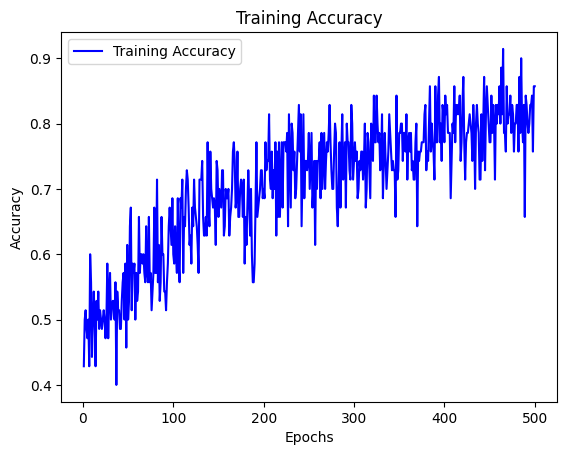

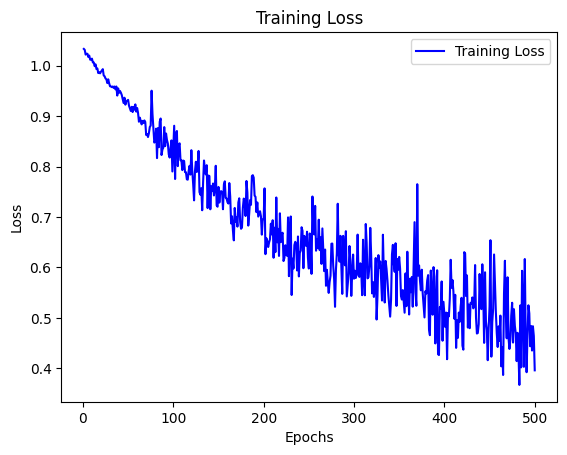

In [ ]:
import matplotlib.pyplot as plt

# Eğitim sürecinin geçmişini al
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=500)

# Eğitim ve doğrulama setlerindeki doğruluk değerlerini al
train_accuracy = history.history['accuracy']
# doğrulama_accuracy = history.history['val_accuracy'] # Eğer bir doğrulama setiniz varsa

# Eğitim ve doğrulama setlerindeki kayıp değerlerini al
train_loss = history.history['loss']
# doğrulama_loss = history.history['val_loss'] # Eğer bir doğrulama setiniz varsa

# Eğitim ve doğrulama setlerindeki doğruluk grafiğini çiz
epochs = range(1, len(train_accuracy) + 1)
plt.plot(epochs, train_accuracy, 'b', label='Training Accuracy')
# plt.plot(epochs, doğrulama_accuracy, 'r', label='Validation Accuracy') # Eğer bir doğrulama setiniz varsa
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Eğitim ve doğrulama setlerindeki kayıp grafiğini çiz
plt.plot(epochs, train_loss, 'b', label='Training Loss')
# plt.plot(epochs, doğrulama_loss, 'r', label='Validation Loss') # Eğer bir doğrulama setiniz varsa
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# **60 lık veriler model**

In [ ]:
import os
import zipfile
from google.colab import drive
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

# Google Drive'a bağlanın
drive.mount('/content/drive')

# ZIP dosyalarını çıkartın
zararli_klasoru = '/content/drive/My Drive/zararlı-zararsızGraf/z-cleaned_codes_Graf'
zararsiz_klasoru = '/content/drive/My Drive/zararlı-zararsızGraf/cleaned_codes_Graf'

# Zararlı ve zararsız dosya listelerini alın
zararli_dosyalar = os.listdir(zararli_klasoru)
zararsiz_dosyalar = os.listdir(zararsiz_klasoru)

# Dosya sayılarını kontrol edin
print("Zararlı Dosya Sayısı:", len(zararli_dosyalar))
print("Zararsız Dosya Sayısı:", len(zararsiz_dosyalar))

# Dosya yollarını oluşturun
zararli_dosya_yollari = [os.path.join(zararli_klasoru, dosya) for dosya in zararli_dosyalar]
zararsiz_dosya_yollari = [os.path.join(zararsiz_klasoru, dosya) for dosya in zararsiz_dosyalar]

# Zararlı ve zararsız dosyaların etiketlerini oluşturun
zararli_etiketleri = [1] * len(zararli_dosya_yollari)
zararsiz_etiketleri = [0] * len(zararsiz_dosya_yollari)

# Tüm dosya yollarını ve etiketleri birleştirin
dosya_yollari = zararli_dosya_yollari + zararsiz_dosya_yollari
etiketler = zararli_etiketleri + zararsiz_etiketleri

# Veri setini karıştırın
dosya_yollari, etiketler = shuffle(dosya_yollari, etiketler)

# Veri setini eğitim ve test olarak bölmek
train_dosyalar, test_dosyalar, train_etiketler, test_etiketler = train_test_split(dosya_yollari, etiketler, test_size=0.2, random_state=42)

# Eğitim veri setini, eğitim ve doğrulama olarak ikiye bölmek
train_dosyalar, val_dosyalar, train_etiketler, val_etiketler = train_test_split(train_dosyalar, train_etiketler, test_size=0.1, random_state=42)

# Eğitim ve test veri setlerinin boyutlarını yazdırın
print("Eğitim Veri Seti Boyutu:", len(train_dosyalar))
print("Doğrulama Veri Seti Boyutu:", len(val_dosyalar))
print("Test Veri Seti Boyutu:", len(test_dosyalar))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zararlı Dosya Sayısı: 49
Zararsız Dosya Sayısı: 43
Eğitim Veri Seti Boyutu: 65
Doğrulama Veri Seti Boyutu: 8
Test Veri Seti Boyutu: 19


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support

# Veri yollarını belirleyelim

v1_klasoru = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/z-cleaned_codes_Graf'
v0_klasoru = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/cleaned_codes_Graf'

# Veri yollarındaki dosyaların boyutu
img_height = 224
img_width = 224
batch_size = 4  # Batch boyutunu düşük tutmak için

# Veri yollarını birleştirerek veri oluşturalım
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']   # belirli sınıfları belirtiyoruz
)

# Modeli oluşturalım
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(512, activation='relu')(x)  # Örnek olarak, yoğun katmanı genişlettik
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Modeli derleyelim
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Modeli eğitelim
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples//train_generator.batch_size,
    epochs=50,
    validation_data=val_generator,  # Ayrı bir doğrulama seti kullanarak
    validation_steps=val_generator.samples//val_generator.batch_size,
    callbacks=[early_stopping]
)

# Tahminler ve gerçek etiketler
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

# Precision, recall, F1-score hesapla
precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
58889256/58889256 [==============================] - 3s 0us/step
Epoch 1/50
18/18 [==============================] - 86s 5s/step - loss: 0.9688 - accuracy: 0.5070 - val_loss: 0.7214 - val_accuracy: 0.5000
Epoch 2/50
18/18 [==============================] - 5s 295ms/step - loss: 0.9408 - accuracy: 0.4507 - val_loss: 0.9294 - val_accuracy: 0.5000
Epoch 3/50
18/18 [==============================] - 6s 314ms/step - loss: 0.9522 - accuracy: 0.4085 - val_loss: 0.6853 - val_accuracy: 0.5625
Epoch 4/50
18/18 [==============================] - 5s 300ms/step - loss: 0.8351 - accuracy: 0.5211 - val_loss: 0.7177 - val_accuracy: 0.5625
Epoch 5/50
18/18 [==============================] - 6s 309ms/step - loss: 0.8011 - accuracy: 0.5070 - val_loss: 0.7839 - val_accuracy: 0.5000
Epoch 6/50
5/5 [==============================] - 2s 459ms/step
Weighted Precision: 0.28027681660899656
Weighted Recall: 0.5294117647058824
Weighte

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support

# Veri yollarını belirleyelim
v1_klasoru = '/content/drive/My Drive/zararlı-zararsızGraf/z-cleaned_codes_Graf'
v0_klasoru = '/content/drive/My Drive/zararlı-zararsızGraf/cleaned_codes_Graf'

# Veri yollarındaki dosyaların boyutu
img_height = 224
img_width = 224
batch_size = 4  # Batch boyutunu düşük tutmak için

# Veri yollarını birleştirerek veri oluşturalım
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True  # Dikey kaydırma ekleyin
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']   # belirli sınıfları belirtiyoruz
)

# Modeli oluşturalım
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

for layer in base_model.layers:
    layer.trainable = True

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)  # Örnek olarak, yoğun katmanı genişlettik
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Adam optimizer kullanın
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Modeli eğitelim
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples//train_generator.batch_size,
    epochs=50,
    validation_data=val_generator,  # Ayrı bir doğrulama seti kullanarak
    validation_steps=val_generator.samples//val_generator.batch_size,
    callbacks=[early_stopping]
)

# Tahminler ve gerçek etiketler
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

# Precision, recall, F1-score hesapla
precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
16705208/16705208 [==============================] - 2s 0us/step
Epoch 1/50
18/18 [==============================] - 41s 400ms/step - loss: 0.7332 - accuracy: 0.4648 - val_loss: 0.7801 - val_accuracy: 0.4375
Epoch 2/50
18/18 [==============================] - 5s 303ms/step - loss: 0.6269 - accuracy: 0.6056 - val_loss: 0.7008 - val_accuracy: 0.5000
Epoch 3/50
18/18 [==============================] - 5s 310ms/step - loss: 0.7140 - accuracy: 0.5070 - val_loss: 0.6938 - val_accuracy: 0.5000
Epoch 4/50
18/18 [==============================] - 6s 327ms/step - loss: 0.7008 - accuracy: 0.5775 - val_loss: 0.6915 - val_accuracy: 0.5625
Epoch 5/50
18/18 [==============================] - 5s 300ms/step - loss: 0.6364 - accuracy: 0.6197 - val_loss: 0.6959 - val_accuracy: 0.4375
Epoch 6/50
18/18 [==============================] - 5s 288ms/step - loss: 0.6124 - accuracy: 0.6338 - val_loss: 0.7077 - val_accuracy: 0.4375
Ep

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support

# Veri yollarını belirleyelim
v1_klasoru = '/content/drive/My Drive/zararlı-zararsızGraf/z-cleaned_codes_Graf'
v0_klasoru = '/content/drive/My Drive/zararlı-zararsızGraf/cleaned_codes_Graf'

# Veri yollarındaki dosyaların boyutu
img_height = 224
img_width = 224
batch_size = 4  # Batch boyutunu düşük tutmak için

# Veri yollarını birleştirerek veri oluşturalım
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True  # Dikey kaydırma ekleyin
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']   # belirli sınıfları belirtiyoruz
)

# Modeli oluşturalım
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

for layer in base_model.layers:
    layer.trainable = True

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)  # Örnek olarak, yoğun katmanı genişlettik
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Adam optimizer kullanın
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Modeli eğitelim
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples//train_generator.batch_size,
    epochs=50,
    validation_data=val_generator,  # Ayrı bir doğrulama seti kullanarak
    validation_steps=val_generator.samples//val_generator.batch_size,
    callbacks=[early_stopping]
)

# Tahminler ve gerçek etiketler
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

# Precision, recall, F1-score hesapla
precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
Epoch 1/50
18/18 [==============================] - 37s 380ms/step - loss: 0.7221 - accuracy: 0.4930 - val_loss: 0.6873 - val_accuracy: 0.5625
Epoch 2/50
18/18 [==============================] - 5s 305ms/step - loss: 0.6584 - accuracy: 0.6620 - val_loss: 0.6868 - val_accuracy: 0.5625
Epoch 3/50
18/18 [==============================] - 6s 309ms/step - loss: 0.6808 - accuracy: 0.5070 - val_loss: 0.6894 - val_accuracy: 0.5625
Epoch 4/50
18/18 [==============================] - 6s 309ms/step - loss: 0.6792 - accuracy: 0.5775 - val_loss: 0.6945 - val_accuracy: 0.5000
Epoch 5/50
18/18 [==============================] - 5s 290ms/step - loss: 0.6643 - accuracy: 0.6479 - val_loss: 0.6954 - val_accuracy: 0.5000
Epoch 6/50
18/18 [==============================] - 6s 306ms/step - loss: 0.6677 - accuracy: 0.5211 - val_loss: 0.6881 - val_accuracy: 0.5625
Epoch 7/50
5/5 [==============================] - 2s 201ms/step
Wei

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support

# Veri yollarını belirleyelim
v1_klasoru = '/content/drive/My Drive/zararlı-zararsızGraf/z-cleaned_codes_Graf'
v0_klasoru = '/content/drive/My Drive/zararlı-zararsızGraf/cleaned_codes_Graf'

# Veri yollarındaki dosyaların boyutu
img_height = 224
img_width = 224
batch_size = 4  # Batch boyutunu düşük tutmak için

# Veri yollarını birleştirerek veri oluşturalım
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True  # Dikey kaydırma ekleyin
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

# Modeli oluşturalım
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)  # Örnek olarak, yoğun katmanı genişlettik
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Adam optimizer kullanın
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Modeli eğitelim
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=50,
    validation_data=val_generator,  # Ayrı bir doğrulama seti kullanarak
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping]
)
# Tahminler ve gerçek etiketler
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

# Precision, recall, F1-score hesapla
precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
80134624/80134624 [==============================] - 4s 0us/step
Epoch 1/50
18/18 [==============================] - 7s 319ms/step - loss: 0.8023 - accuracy: 0.4789 - val_loss: 0.6884 - val_accuracy: 0.5625
Epoch 2/50
18/18 [==============================] - 6s 310ms/step - loss: 0.7159 - accuracy: 0.5070 - val_loss: 0.6848 - val_accuracy: 0.5625
Epoch 3/50
18/18 [==============================] - 5s 289ms/step - loss: 0.7229 - accuracy: 0.4861 - val_loss: 0.6863 - val_accuracy: 0.5625
Epoch 4/50
18/18 [==============================] - 6s 325ms/step - loss: 0.7644 - accuracy: 0.4366 - val_loss: 0.6839 - val_accuracy: 0.5625
Epoch 5/50
18/18 [==============================] - 5s 288ms/step - loss: 0.7010 - accuracy: 0.5493 - val_loss: 0.6852 - val_accuracy: 0.5625
Epoch 6/50
18/18 [==============================] - 5s 285ms/step - loss: 0.7151 - accuracy: 0.5352 - val_loss: 0.6847 - val_accuracy: 0.5625
Epo

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support

# Veri yollarını belirleyelim
v1_klasoru = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/z-cleaned_codes_Graf'
v0_klasoru = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/cleaned_codes_Graf'

# Veri yollarındaki dosyaların boyutu
img_height = 224
img_width = 224
batch_size = 4  # Batch boyutunu düşük tutmak için

# Veri yollarını birleştirerek veri oluşturalım
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True  # Dikey kaydırma ekleyin
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf',  # ana klasör
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # binary olarak ayarlayın
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']  # belirli sınıfları belirtiyoruz
)

# Modeli oluşturalım
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(512, activation='relu')(x)  # Örnek olarak, yoğun katmanı genişlettik
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Adam optimizer kullanın
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Modeli eğitelim
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=50,
    validation_data=val_generator,  # Ayrı bir doğrulama seti kullanarak
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping]
)

# Tahminler ve gerçek etiketler
predictions = model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

# Precision, recall, F1-score hesapla
precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 0 images belonging to 2 classes.
Found 0 images belonging to 2 classes.
9406464/9406464 [==============================] - 0s 0us/step


ValueError: Unexpected value for `steps_per_epoch`. Received value is 0. Please check the docstring for `model.fit()` for supported values.